In [28]:
# Cell 1 — Environment check
# CM3015 Breast Cancer Detection
# Notebook 01: Dataset Setup and EDA

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
print(f"TensorFlow: {tf.__version__}")
print(f"GPUs: {tf.config.list_physical_devices('GPU')}")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")

TensorFlow: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
NumPy: 2.0.2
Pandas: 2.3.3


In [29]:
# Cell 2 — Confirm what is attached
print("=== /kaggle/input contents ===")
for item in sorted(os.listdir('/kaggle/input')):
    print(f"\n[{item}]")
    subpath = f'/kaggle/input/{item}'
    try:
        contents = sorted(os.listdir(subpath))
        for f in contents[:8]:  # show first 8 items only
            print(f"    {f}")
        if len(contents) > 8:
            print(f"    ... and {len(contents)-8} more")
    except:
        print("    (could not read)")

=== /kaggle/input contents ===

[datasets]
    awsaf49
    mfjmrizvi


In [30]:
# Cell 3 — Deep folder inspection
import os

def show_tree(path, depth=0, max_depth=4, max_files=5):
    if depth > max_depth:
        return
    try:
        items = sorted(os.listdir(path))
        files = [i for i in items if os.path.isfile(f'{path}/{i}')]
        dirs  = [i for i in items if os.path.isdir(f'{path}/{i}')]
        
        for d in dirs:
            print('    ' * depth + f'[{d}/]')
            show_tree(f'{path}/{d}', depth+1, max_depth, max_files)
        
        for f in files[:max_files]:
            size = os.path.getsize(f'{path}/{f}')
            print('    ' * depth + f'{f} ({size/1024:.1f} KB)')
        
        if len(files) > max_files:
            print('    ' * depth + f'... and {len(files)-max_files} more files')
    except Exception as e:
        print('    ' * depth + f'ERROR: {e}')

print("=== FULL INPUT TREE ===")
show_tree('/kaggle/input', max_depth=4)

=== FULL INPUT TREE ===
[datasets/]
    [awsaf49/]
        [cbis-ddsm-breast-cancer-image-dataset/]
            [csv/]
                calc_case_description_test_set.csv (185.9 KB)
                calc_case_description_train_set.csv (903.6 KB)
                dicom_info.csv (6201.6 KB)
                mass_case_description_test_set.csv (212.0 KB)
                mass_case_description_train_set.csv (754.6 KB)
                ... and 1 more files
            [jpeg/]
                [1.3.6.1.4.1.9590.100.1.2.100018879311824535125115145152454291132/]
                [1.3.6.1.4.1.9590.100.1.2.100131208110604806117271735422083351547/]
                [1.3.6.1.4.1.9590.100.1.2.100522099512256189513864912954167862869/]
                [1.3.6.1.4.1.9590.100.1.2.100522676511025180541602449080267145647/]
                [1.3.6.1.4.1.9590.100.1.2.10055294210766234140934516480682841962/]
                [1.3.6.1.4.1.9590.100.1.2.100579676611077714807988832023693299884/]
                [1.3.6.1.4.1

In [31]:
# Cell 4 — Define all paths
# Based on confirmed folder structure from Cell 3

# Base paths
AWSAF_BASE  = '/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset'
LABELS_BASE = '/kaggle/input/datasets/mfjmrizvi/cbis-ddsm-tcia-labels'
OUTPUT      = '/kaggle/working'

# CSV paths — using YOUR official TCIA versions
MASS_TRAIN_CSV = f'{LABELS_BASE}/mass_case_description_train_set.csv'
MASS_TEST_CSV  = f'{LABELS_BASE}/mass_case_description_test_set.csv'
CALC_TRAIN_CSV = f'{LABELS_BASE}/calc_case_description_train_set.csv'
CALC_TEST_CSV  = f'{LABELS_BASE}/calc_case_description_test_set.csv'

# Awsaf CSV paths (we use dicom_info.csv from here only)
DICOM_INFO_CSV = f'{AWSAF_BASE}/csv/dicom_info.csv'
META_CSV       = f'{AWSAF_BASE}/csv/meta.csv'

# Image root
JPEG_ROOT = f'{AWSAF_BASE}/jpeg'

# Verify all paths exist
paths = {
    'MASS_TRAIN_CSV': MASS_TRAIN_CSV,
    'MASS_TEST_CSV':  MASS_TEST_CSV,
    'CALC_TRAIN_CSV': CALC_TRAIN_CSV,
    'CALC_TEST_CSV':  CALC_TEST_CSV,
    'DICOM_INFO_CSV': DICOM_INFO_CSV,
    'META_CSV':       META_CSV,
    'JPEG_ROOT':      JPEG_ROOT,
}

print("=== PATH VERIFICATION ===")
all_ok = True
for name, path in paths.items():
    exists = os.path.exists(path)
    status = "✓" if exists else "✗ MISSING"
    print(f"  {status}  {name}: {path}")
    if not exists:
        all_ok = False

print(f"\nAll paths OK: {all_ok}")

=== PATH VERIFICATION ===
  ✓  MASS_TRAIN_CSV: /kaggle/input/datasets/mfjmrizvi/cbis-ddsm-tcia-labels/mass_case_description_train_set.csv
  ✓  MASS_TEST_CSV: /kaggle/input/datasets/mfjmrizvi/cbis-ddsm-tcia-labels/mass_case_description_test_set.csv
  ✓  CALC_TRAIN_CSV: /kaggle/input/datasets/mfjmrizvi/cbis-ddsm-tcia-labels/calc_case_description_train_set.csv
  ✓  CALC_TEST_CSV: /kaggle/input/datasets/mfjmrizvi/cbis-ddsm-tcia-labels/calc_case_description_test_set.csv
  ✓  DICOM_INFO_CSV: /kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/csv/dicom_info.csv
  ✓  META_CSV: /kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/csv/meta.csv
  ✓  JPEG_ROOT: /kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/jpeg

All paths OK: True


In [32]:
# Cell 5 — Load all CSV files

mass_train = pd.read_csv(MASS_TRAIN_CSV)
mass_test  = pd.read_csv(MASS_TEST_CSV)
calc_train = pd.read_csv(CALC_TRAIN_CSV)
calc_test  = pd.read_csv(CALC_TEST_CSV)
dicom_info = pd.read_csv(DICOM_INFO_CSV)
meta       = pd.read_csv(META_CSV)

print("=== SHAPES ===")
print(f"mass_train:  {mass_train.shape}")
print(f"mass_test:   {mass_test.shape}")
print(f"calc_train:  {calc_train.shape}")
print(f"calc_test:   {calc_test.shape}")
print(f"dicom_info:  {dicom_info.shape}")
print(f"meta:        {meta.shape}")

=== SHAPES ===
mass_train:  (1318, 14)
mass_test:   (378, 14)
calc_train:  (1546, 14)
calc_test:   (326, 14)
dicom_info:  (10237, 38)
meta:        (6775, 9)


In [33]:
# Cell 6 — Print exact column names
# Do not skip this — every downstream cell depends on these

print("=== MASS TRAIN COLUMNS ===")
for i, col in enumerate(mass_train.columns):
    print(f"  [{i:2d}] '{col}'")

print("\n=== CALC TRAIN COLUMNS ===")
for i, col in enumerate(calc_train.columns):
    print(f"  [{i:2d}] '{col}'")

print("\n=== DICOM INFO COLUMNS ===")
for i, col in enumerate(dicom_info.columns):
    print(f"  [{i:2d}] '{col}'")

print("\n=== META COLUMNS ===")
for i, col in enumerate(meta.columns):
    print(f"  [{i:2d}] '{col}'")

=== MASS TRAIN COLUMNS ===
  [ 0] 'patient_id'
  [ 1] 'breast_density'
  [ 2] 'left or right breast'
  [ 3] 'image view'
  [ 4] 'abnormality id'
  [ 5] 'abnormality type'
  [ 6] 'mass shape'
  [ 7] 'mass margins'
  [ 8] 'assessment'
  [ 9] 'pathology'
  [10] 'subtlety'
  [11] 'image file path'
  [12] 'cropped image file path'
  [13] 'ROI mask file path'

=== CALC TRAIN COLUMNS ===
  [ 0] 'patient_id'
  [ 1] 'breast density'
  [ 2] 'left or right breast'
  [ 3] 'image view'
  [ 4] 'abnormality id'
  [ 5] 'abnormality type'
  [ 6] 'calc type'
  [ 7] 'calc distribution'
  [ 8] 'assessment'
  [ 9] 'pathology'
  [10] 'subtlety'
  [11] 'image file path'
  [12] 'cropped image file path'
  [13] 'ROI mask file path'

=== DICOM INFO COLUMNS ===
  [ 0] 'file_path'
  [ 1] 'image_path'
  [ 2] 'AccessionNumber'
  [ 3] 'BitsAllocated'
  [ 4] 'BitsStored'
  [ 5] 'BodyPartExamined'
  [ 6] 'Columns'
  [ 7] 'ContentDate'
  [ 8] 'ContentTime'
  [ 9] 'ConversionType'
  [10] 'HighBit'
  [11] 'InstanceNumber

In [34]:
# Cell 7 — Exact pathology string values

print("=== MASS TRAIN PATHOLOGY ===")
print(mass_train['pathology'].value_counts())
print("Unique:", mass_train['pathology'].unique())

print("\n=== MASS TEST PATHOLOGY ===")
print(mass_test['pathology'].value_counts())
print("Unique:", mass_test['pathology'].unique())

print("\n=== CALC TRAIN PATHOLOGY ===")
print(calc_train['pathology'].value_counts())
print("Unique:", calc_train['pathology'].unique())

print("\n=== CALC TEST PATHOLOGY ===")
print(calc_test['pathology'].value_counts())
print("Unique:", calc_test['pathology'].unique())

=== MASS TRAIN PATHOLOGY ===
pathology
MALIGNANT                  637
BENIGN                     577
BENIGN_WITHOUT_CALLBACK    104
Name: count, dtype: int64
Unique: ['MALIGNANT' 'BENIGN' 'BENIGN_WITHOUT_CALLBACK']

=== MASS TEST PATHOLOGY ===
pathology
BENIGN                     194
MALIGNANT                  147
BENIGN_WITHOUT_CALLBACK     37
Name: count, dtype: int64
Unique: ['MALIGNANT' 'BENIGN' 'BENIGN_WITHOUT_CALLBACK']

=== CALC TRAIN PATHOLOGY ===
pathology
MALIGNANT                  544
BENIGN                     528
BENIGN_WITHOUT_CALLBACK    474
Name: count, dtype: int64
Unique: ['MALIGNANT' 'BENIGN' 'BENIGN_WITHOUT_CALLBACK']

=== CALC TEST PATHOLOGY ===
pathology
BENIGN                     130
MALIGNANT                  129
BENIGN_WITHOUT_CALLBACK     67
Name: count, dtype: int64
Unique: ['BENIGN' 'BENIGN_WITHOUT_CALLBACK' 'MALIGNANT']


In [35]:
# Cell 8 — Missing value audit

print("=== MISSING VALUES — MASS TRAIN ===")
m_missing = mass_train.isnull().sum()
print(m_missing[m_missing > 0])
print(f"Total missing cells: {m_missing.sum()}")

print("\n=== MISSING VALUES — CALC TRAIN ===")
c_missing = calc_train.isnull().sum()
print(c_missing[c_missing > 0])
print(f"Total missing cells: {c_missing.sum()}")

=== MISSING VALUES — MASS TRAIN ===
mass shape       4
mass margins    43
dtype: int64
Total missing cells: 47

=== MISSING VALUES — CALC TRAIN ===
calc type             20
calc distribution    376
dtype: int64
Total missing cells: 396


In [36]:
# Cell 9 — Inspect dicom_info to understand image linking (fixed)

print("=== DICOM INFO FIRST 3 ROWS ===")
display(dicom_info.head(3))

print("\n=== SAMPLE SeriesInstanceUID values ===")
if 'SeriesInstanceUID' in dicom_info.columns:
    print(dicom_info['SeriesInstanceUID'].iloc[:3].tolist())

print("\n=== SAMPLE image file path from dicom_info ===")
for col in dicom_info.columns:
    non_null = dicom_info[col].dropna()
    if len(non_null) == 0:
        continue  # skip entirely null columns
    sample = str(non_null.iloc[0])
    if any(x in sample for x in
           ['1.3.6', 'jpeg', 'jpg', '/', 'CBIS', 'Mass', 'Calc']):
        print(f"  Column '{col}': {sample[:100]}")

=== DICOM INFO FIRST 3 ROWS ===


,file_path,image_path,AccessionNumber,BitsAllocated,BitsStored,BodyPartExamined,Columns,ContentDate,ContentTime,ConversionType,...,SecondaryCaptureDeviceManufacturerModelName,SeriesDescription,SeriesInstanceUID,SeriesNumber,SmallestImagePixelValue,SpecificCharacterSet,StudyDate,StudyID,StudyInstanceUID,StudyTime
0,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.12930...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.129308...,NaN,16,16,BREAST,351,20160426,131732.685,WSD,...,MATLAB,cropped images,1.3.6.1.4.1.9590.100.1.2.129308726812851964007...,1,23078,ISO_IR 100,20160720.0,DDSM,1.3.6.1.4.1.9590.100.1.2.271867287611061855725...,214951.0
1,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.24838...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.248386...,NaN,16,16,BREAST,3526,20160426,143829.101,WSD,...,MATLAB,full mammogram images,1.3.6.1.4.1.9590.100.1.2.248386742010678582309...,1,0,ISO_IR 100,20160720.0,DDSM,1.3.6.1.4.1.9590.100.1.2.161516517311681906612...,193426.0
2,CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.26721...,CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.267213...,NaN,16,16,BREAST,1546,20160503,111956.298,WSD,...,MATLAB,full mammogram images,1.3.6.1.4.1.9590.100.1.2.267213171011171858918...,1,0,ISO_IR 100,20160807.0,DDSM,1.3.6.1.4.1.9590.100.1.2.291043622711253836701...,161814.0



=== SAMPLE SeriesInstanceUID values ===
['1.3.6.1.4.1.9590.100.1.2.129308726812851964007517874181459556304', '1.3.6.1.4.1.9590.100.1.2.248386742010678582309005372213277814849', '1.3.6.1.4.1.9590.100.1.2.267213171011171858918434139331210917771']

=== SAMPLE image file path from dicom_info ===
  Column 'file_path': CBIS-DDSM/dicom/1.3.6.1.4.1.9590.100.1.2.129308726812851964007517874181459556304/1-172.dcm
  Column 'image_path': CBIS-DDSM/jpeg/1.3.6.1.4.1.9590.100.1.2.129308726812851964007517874181459556304/1-172.jpg
  Column 'PatientID': Mass-Training_P_01265_RIGHT_MLO_1
  Column 'PatientName': Mass-Training_P_01265_RIGHT_MLO_1
  Column 'SOPInstanceUID': 1.3.6.1.4.1.9590.100.1.2.426380754911844882201419900442081103076
  Column 'SeriesInstanceUID': 1.3.6.1.4.1.9590.100.1.2.129308726812851964007517874181459556304
  Column 'StudyInstanceUID': 1.3.6.1.4.1.9590.100.1.2.271867287611061855725036643043149877819


Total image folders: 6774
First folder name: 1.3.6.1.4.1.9590.100.1.2.100018879311824535125115145152454291132
Contents of first folder: ['2-241.jpg', '1-263.jpg']

First image found: /kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.426013102412536473840491086280519425818/1-223.jpg
Image shape: (5696, 4008)
Image dtype: uint8
Pixel range: 0 to 255


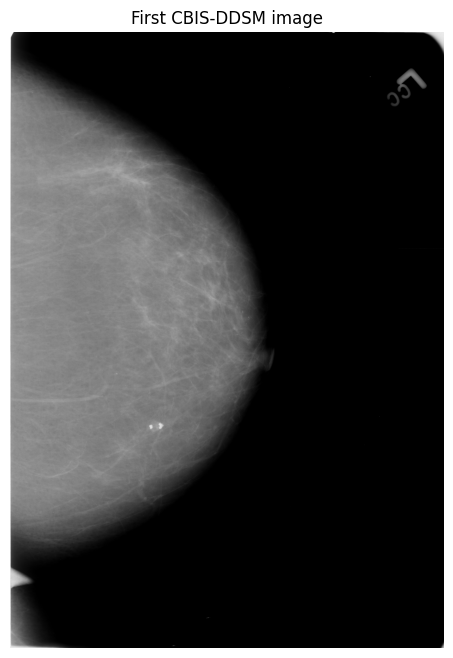

In [37]:
# Cell 10 — Load and display one image
# Confirms images are readable before we build any pipeline

import matplotlib.image as mpimg

# Get first folder in jpeg directory
jpeg_folders = sorted(os.listdir(JPEG_ROOT))
print(f"Total image folders: {len(jpeg_folders)}")
print(f"First folder name: {jpeg_folders[0]}")

# Go into first folder and find image
first_folder = f'{JPEG_ROOT}/{jpeg_folders[0]}'
subfolders = os.listdir(first_folder)
print(f"Contents of first folder: {subfolders}")

# Keep going deeper until we find a jpg file
def find_first_image(base_path, extensions=('.jpg', '.jpeg')):
    for root, dirs, files in os.walk(base_path):
        for f in files:
            if f.lower().endswith(extensions):
                return os.path.join(root, f)
    return None

img_path = find_first_image(JPEG_ROOT)
print(f"\nFirst image found: {img_path}")

if img_path:
    img = mpimg.imread(img_path)
    print(f"Image shape: {img.shape}")
    print(f"Image dtype: {img.dtype}")
    print(f"Pixel range: {img.min()} to {img.max()}")
    
    plt.figure(figsize=(6, 8))
    plt.imshow(img, cmap='gray')
    plt.title('First CBIS-DDSM image')
    plt.axis('off')
    plt.savefig(f'{OUTPUT}/first_image.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No image found — check folder structure")

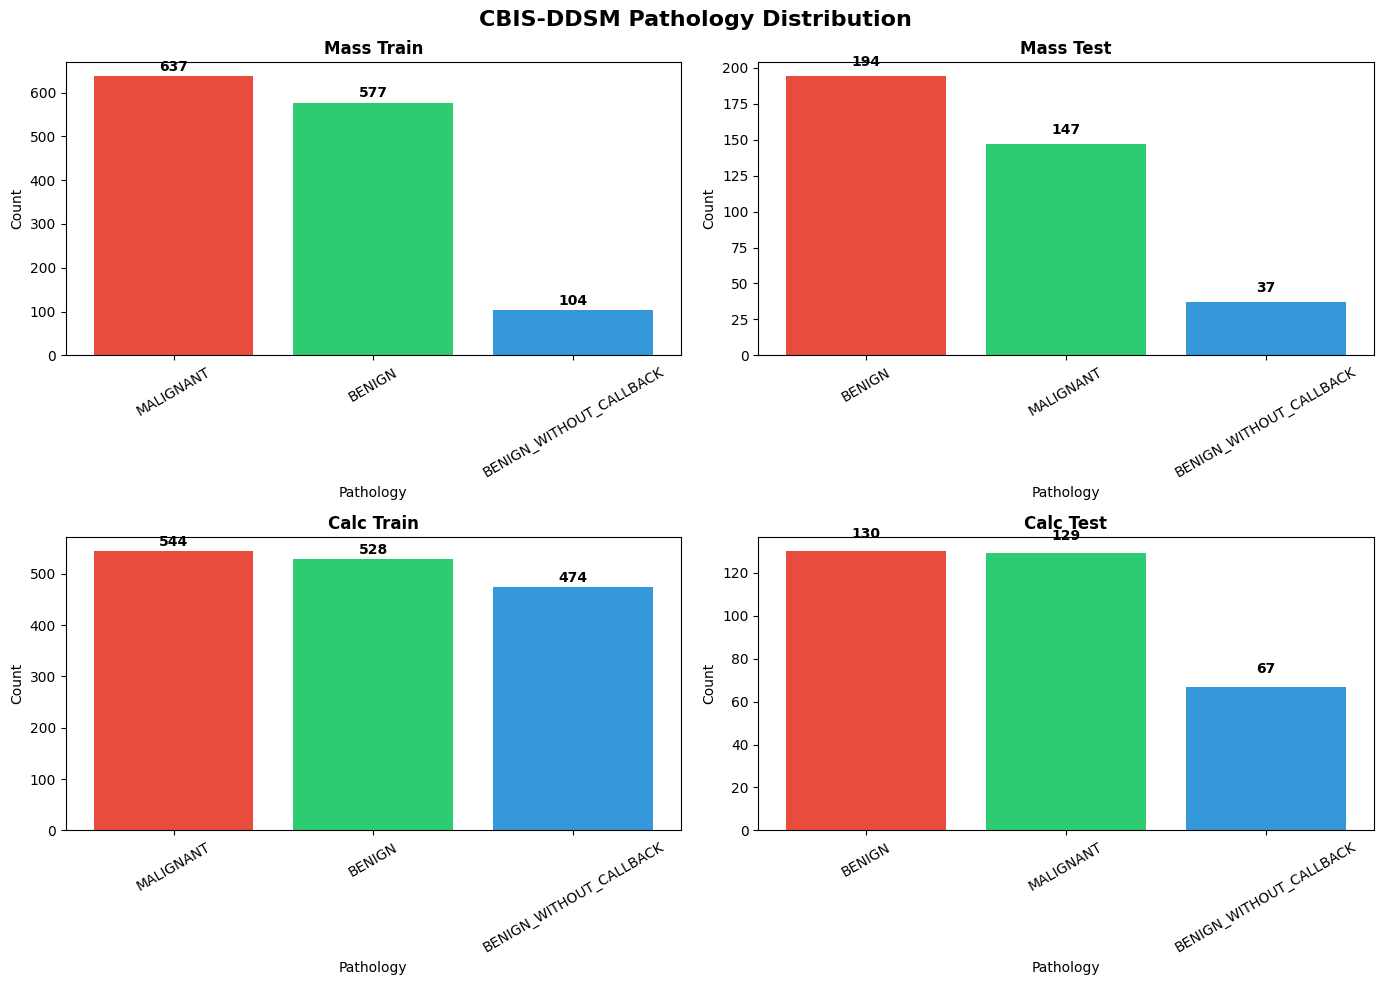

Plot saved


In [38]:
# Cell 11 — Class distribution plot

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('CBIS-DDSM Pathology Distribution', fontsize=16, fontweight='bold')

datasets = [
    (mass_train, 'Mass Train', axes[0,0]),
    (mass_test,  'Mass Test',  axes[0,1]),
    (calc_train, 'Calc Train', axes[1,0]),
    (calc_test,  'Calc Test',  axes[1,1]),
]

colors = ['#e74c3c', '#2ecc71', '#3498db']

for df, title, ax in datasets:
    counts = df['pathology'].value_counts()
    bars = ax.bar(counts.index, counts.values, color=colors[:len(counts)])
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Pathology')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=30)
    # Add count labels on bars
    for bar, count in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, 
                bar.get_height() + 5,
                str(count), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUT}/pathology_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved")

In [39]:
# Cell 12 — Binary label mapping
# BENIGN_WITHOUT_CALLBACK → merged with BENIGN
# Final: 0 = benign, 1 = malignant

def binarise_pathology(df):
    df = df.copy()
    df['label'] = df['pathology'].map({
        'MALIGNANT':             1,
        'BENIGN':                0,
        'BENIGN_WITHOUT_CALLBACK': 0
    })
    return df

mass_train = binarise_pathology(mass_train)
mass_test  = binarise_pathology(mass_test)
calc_train = binarise_pathology(calc_train)
calc_test  = binarise_pathology(calc_test)

print("=== BINARY LABEL DISTRIBUTION ===")
print("\nMass Train:")
print(mass_train['label'].value_counts())
print(f"Imbalance ratio: {mass_train['label'].value_counts()[0] / mass_train['label'].value_counts()[1]:.2f}:1 (benign:malignant)")

print("\nMass Test:")
print(mass_test['label'].value_counts())

print("\nCalc Train:")
print(calc_train['label'].value_counts())

print("\nCalc Test:")
print(calc_test['label'].value_counts())

# Check for any unmapped values
print("\nNull labels in mass_train:", mass_train['label'].isnull().sum())
print("Null labels in calc_train:", calc_train['label'].isnull().sum())

=== BINARY LABEL DISTRIBUTION ===

Mass Train:
label
0    681
1    637
Name: count, dtype: int64
Imbalance ratio: 1.07:1 (benign:malignant)

Mass Test:
label
0    231
1    147
Name: count, dtype: int64

Calc Train:
label
0    1002
1     544
Name: count, dtype: int64

Calc Test:
label
0    197
1    129
Name: count, dtype: int64

Null labels in mass_train: 0
Null labels in calc_train: 0


In [40]:
# Cell 13 — Build image path linking function
# Links CSV rows to actual JPEG files via dicom_info.csv

# The dicom_info image_path looks like:
# CBIS-DDSM/jpeg/<SeriesUID>/<filename>.jpg
# We need to convert to:
# /kaggle/input/datasets/awsaf49/.../jpeg/<SeriesUID>/<filename>.jpg

def extract_series_uid(path_str):
    """
    Extract SeriesInstanceUID from a path string like:
    CBIS-DDSM/jpeg/1.3.6.1.4.../1-172.jpg
    Returns the UID portion only
    """
    if pd.isna(path_str):
        return None
    parts = str(path_str).replace('\\', '/').split('/')
    # Find the part that looks like a DICOM UID (starts with 1.3.6)
    for part in parts:
        if part.startswith('1.3.6'):
            return part
    return None

# Build a lookup: SeriesUID → full Kaggle jpeg path
# Filter dicom_info to full mammogram images only
full_mammo = dicom_info[
    dicom_info['SeriesDescription'] == 'full mammogram images'
].copy()

print(f"Full mammogram entries in dicom_info: {len(full_mammo)}")
print(f"Cropped image entries: {len(dicom_info[dicom_info['SeriesDescription'] == 'cropped images'])}")
print(f"Other entries: {len(dicom_info[~dicom_info['SeriesDescription'].isin(['full mammogram images','cropped images'])])}")

# Show unique SeriesDescription values
print("\nAll SeriesDescription values:")
print(dicom_info['SeriesDescription'].value_counts())

Full mammogram entries in dicom_info: 2857
Cropped image entries: 3567
Other entries: 3813

All SeriesDescription values:
SeriesDescription
cropped images           3567
ROI mask images          3247
full mammogram images    2857
Name: count, dtype: int64


In [41]:
# Cell 13b — Fixed UID extraction function

def extract_series_uid(path_str):
    """
    Extract the SECOND SeriesInstanceUID from a CSV path string.
    CSV paths look like:
    Mass-Training_P_00001_LEFT_CC/<StudyUID>/<SeriesUID>/000000.dcm
    We want the SeriesUID (second UID = second 1.3.6... segment)
    """
    if pd.isna(path_str):
        return None
    parts = str(path_str).replace('\\', '/').split('/')
    uids = [p for p in parts if p.startswith('1.3.6')]
    if len(uids) >= 2:
        return uids[1]  # second UID is the Series UID
    elif len(uids) == 1:
        return uids[0]
    return None

# Verify the fix with the same test case
test_path = mass_train['image file path'].iloc[0]
print(f"Raw CSV path: {test_path}")
extracted = extract_series_uid(test_path)
print(f"Extracted UID: {extracted}")
print(f"UID in path_map: {extracted in path_map}")

# Quick check across all rows
matches = sum(1 for val in mass_train['image file path']
              if extract_series_uid(val) in path_map)
print(f"\nMatches in mass_train: {matches}/{len(mass_train)}")

matches_test = sum(1 for val in mass_test['image file path']
                   if extract_series_uid(val) in path_map)
print(f"Matches in mass_test:  {matches_test}/{len(mass_test)}")

Raw CSV path: Mass-Training_P_00001_LEFT_CC/1.3.6.1.4.1.9590.100.1.2.422112722213189649807611434612228974994/1.3.6.1.4.1.9590.100.1.2.342386194811267636608694132590482924515/000000.dcm
Extracted UID: 1.3.6.1.4.1.9590.100.1.2.342386194811267636608694132590482924515
UID in path_map: True

Matches in mass_train: 1318/1318
Matches in mass_test:  378/378


In [42]:
# Cell 14 — Build the path mapping
# Map each CSV row's image file path → actual Kaggle file path

def build_path_map(dicom_info_df, jpeg_root):
    """
    Returns a dict: SeriesUID → full Kaggle path to the jpg file
    """
    path_map = {}
    for _, row in dicom_info_df.iterrows():
        img_path = str(row['image_path'])
        uid = extract_series_uid(img_path)
        if uid:
            # Reconstruct full path
            filename = img_path.replace('\\', '/').split('/')[-1]
            full_path = f"{jpeg_root}/{uid}/{filename}"
            path_map[uid] = full_path
    return path_map

path_map = build_path_map(full_mammo, JPEG_ROOT)
print(f"Total paths in map: {len(path_map)}")
print(f"\nSample entry:")
sample_uid = list(path_map.keys())[0]
print(f"  UID:  {sample_uid}")
print(f"  Path: {path_map[sample_uid]}")
print(f"  File exists: {os.path.exists(path_map[sample_uid])}")

Total paths in map: 2857

Sample entry:
  UID:  1.3.6.1.4.1.9590.100.1.2.248386742010678582309005372213277814849
  Path: /kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.248386742010678582309005372213277814849/1-249.jpg
  File exists: True


In [43]:
# Cell 15 — Fixed image path linking

def link_images_to_csv(df, path_map, jpeg_root):
    """
    Links each CSV row to its full mammogram JPEG path.
    Uses the SECOND UID in the CSV image file path (Series UID).
    """
    df = df.copy()
    linked_paths = []

    for _, row in df.iterrows():
        csv_path = str(row['image file path'])
        uid = extract_series_uid(csv_path)

        if uid and uid in path_map:
            linked_paths.append(path_map[uid])
        else:
            linked_paths.append(None)

    df['full_image_path'] = linked_paths
    return df

mass_train_linked = link_images_to_csv(mass_train, path_map, JPEG_ROOT)
mass_test_linked  = link_images_to_csv(mass_test,  path_map, JPEG_ROOT)

# Check linking success
train_linked = mass_train_linked['full_image_path'].notna().sum()
test_linked  = mass_test_linked['full_image_path'].notna().sum()

print(f"Mass train: {train_linked}/{len(mass_train_linked)} rows linked")
print(f"Mass test:  {test_linked}/{len(mass_test_linked)} rows linked")

# Verify a sample row
linked_rows = mass_train_linked[mass_train_linked['full_image_path'].notna()]

if len(linked_rows) > 0:
    sample = linked_rows.iloc[0]
    print(f"\nSample linked row:")
    print(f"  patient_id:    {sample['patient_id']}")
    print(f"  pathology:     {sample['pathology']}")
    print(f"  label:         {sample['label']}")
    print(f"  image path:    {sample['full_image_path']}")
    print(f"  file exists:   {os.path.exists(sample['full_image_path'])}")
else:
    print("ERROR: No linked rows found")

Mass train: 1318/1318 rows linked
Mass test:  378/378 rows linked

Sample linked row:
  patient_id:    P_00001
  pathology:     MALIGNANT
  label:         1
  image path:    /kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/jpeg/1.3.6.1.4.1.9590.100.1.2.342386194811267636608694132590482924515/1-211.jpg
  file exists:   True


In [44]:
# Cell 16 — Save linked dataframes for next notebook

mass_train_linked.to_csv(f'{OUTPUT}/mass_train_linked.csv', index=False)
mass_test_linked.to_csv(f'{OUTPUT}/mass_test_linked.csv',  index=False)

print("Saved:")
print(f"  {OUTPUT}/mass_train_linked.csv")
print(f"  {OUTPUT}/mass_test_linked.csv")
print(f"\nFinal mass_train_linked shape: {mass_train_linked.shape}")
print(f"Final mass_test_linked shape:  {mass_test_linked.shape}")
print(f"\nColumns: {mass_train_linked.columns.tolist()}")

Saved:
  /kaggle/working/mass_train_linked.csv
  /kaggle/working/mass_test_linked.csv

Final mass_train_linked shape: (1318, 16)
Final mass_test_linked shape:  (378, 16)

Columns: ['patient_id', 'breast_density', 'left or right breast', 'image view', 'abnormality id', 'abnormality type', 'mass shape', 'mass margins', 'assessment', 'pathology', 'subtlety', 'image file path', 'cropped image file path', 'ROI mask file path', 'label', 'full_image_path']


In [45]:
# Cell 17 — Final EDA summary save

import json

summary = {
    'dataset': 'CBIS-DDSM via Kaggle (awsaf49)',
    'labels_source': 'Official TCIA download',
    'scope': 'Mass cases only (prototype phase)',
    'label_mapping': {
        'MALIGNANT': 1,
        'BENIGN': 0,
        'BENIGN_WITHOUT_CALLBACK': 0
    },
    'mass_train': {
        'total_rows': len(mass_train_linked),
        'linked_to_image': int(train_linked),
        'label_0_benign': int(mass_train_linked['label'].value_counts()[0]),
        'label_1_malignant': int(mass_train_linked['label'].value_counts()[1]),
    },
    'mass_test': {
        'total_rows': len(mass_test_linked),
        'linked_to_image': int(test_linked),
        'label_0_benign': int(mass_test_linked['label'].value_counts()[0]),
        'label_1_malignant': int(mass_test_linked['label'].value_counts()[1]),
    },
    'image_properties': {
        'format': 'JPEG',
        'dtype': 'uint8',
        'pixel_range': '0-255',
        'sample_shape': '5696x4008 (varies per image)',
        'notes': 'Full mammogram images, high resolution'
    },
    'missing_values': {
        'mass_shape': 4,
        'mass_margins': 43,
        'impact': 'Low — descriptive columns only, not used in pipeline'
    }
}

with open(f'{OUTPUT}/eda_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("EDA complete. Summary saved.")
print(json.dumps(summary, indent=2))

EDA complete. Summary saved.
{
  "dataset": "CBIS-DDSM via Kaggle (awsaf49)",
  "labels_source": "Official TCIA download",
  "scope": "Mass cases only (prototype phase)",
  "label_mapping": {
    "MALIGNANT": 1,
    "BENIGN": 0,
    "BENIGN_WITHOUT_CALLBACK": 0
  },
  "mass_train": {
    "total_rows": 1318,
    "linked_to_image": 1318,
    "label_0_benign": 681,
    "label_1_malignant": 637
  },
  "mass_test": {
    "total_rows": 378,
    "linked_to_image": 378,
    "label_0_benign": 231,
    "label_1_malignant": 147
  },
  "image_properties": {
    "format": "JPEG",
    "dtype": "uint8",
    "pixel_range": "0-255",
    "sample_shape": "5696x4008 (varies per image)",
    "notes": "Full mammogram images, high resolution"
  },
  "missing_values": {
    "mass_shape": 4,
    "mass_margins": 43,
    "impact": "Low \u2014 descriptive columns only, not used in pipeline"
  }
}


In [46]:
# # DIAGNOSTIC CELL — run before fixing anything

# # Step 1: Look at what the CSV 'image file path' column actually contains
# print("=== SAMPLE 'image file path' VALUES FROM MASS_TRAIN ===")
# for i, val in enumerate(mass_train['image file path'].head(5)):
#     print(f"  [{i}] {val}")

# print("\n=== SAMPLE 'image file path' VALUES FROM MASS_TEST ===")
# for i, val in enumerate(mass_test['image file path'].head(3)):
#     print(f"  [{i}] {val}")

# # Step 2: Look at what the path_map keys look like
# print("\n=== SAMPLE PATH_MAP KEYS ===")
# for i, key in enumerate(list(path_map.keys())[:3]):
#     print(f"  [{i}] {key}")

# # Step 3: Try extracting UID from one CSV path manually
# test_path = mass_train['image file path'].iloc[0]
# print(f"\n=== MANUAL UID EXTRACTION TEST ===")
# print(f"Raw CSV path: {test_path}")
# extracted = extract_series_uid(test_path)
# print(f"Extracted UID: {extracted}")
# print(f"UID in path_map: {extracted in path_map}")

# # Step 4: Check if any extracted UIDs match path_map at all
# print("\n=== CHECKING ALL MASS_TRAIN UIDS AGAINST PATH_MAP ===")
# matches = 0
# no_uid = 0
# uid_not_in_map = 0

# for val in mass_train['image file path']:
#     uid = extract_series_uid(val)
#     if uid is None:
#         no_uid += 1
#     elif uid in path_map:
#         matches += 1
#     else:
#         uid_not_in_map += 1

# print(f"  Successful matches: {matches}")
# print(f"  No UID extracted:   {no_uid}")
# print(f"  UID not in map:     {uid_not_in_map}")